# Zooma cross-check: is the assigned ontology correct?

The deterministic trace-back cascade's non-exact strategies (normalized, case-insensitive, ontology synonym, fuzzy, bag of words) find evidence text that isn't a literal match to the value they end up assigning an ontology term to -- that's exactly where a wrong term, or a wrong *ontology*, is most likely to slip in.
This notebook sends every such case's literal evidence phrase to EBI's Zooma text-annotation service, independently of the pipeline's own assumed ontology, and checks whether the pipeline's assigned term agrees with what Zooma proposes.

In [1]:
# TABLE OF CONTENTS
import sys

sys.path.insert(0, "../src")
from notebook_utils import table_of_contents

table_of_contents("zooma_cross_check.ipynb")

### Table of contents


[Zooma cross-check: is the assigned ontology correct?](#Zooma-cross-check:-is-the-assigned-ontology-correct?)
- [Setup](#Setup)
- [Methodology](#Methodology)
- [How often did Zooma find anything at all for the evidence phrase?](#How-often-did-Zooma-find-anything-at-all-for-the-evidence-phrase?)
- [Does the pipeline's assigned term agree with Zooma?](#Does-the-pipeline's-assigned-term-agree-with-Zooma?)
- [Agreement rate by target field](#Agreement-rate-by-target-field)
- [Agreement rate by originating (non-exact) matching strategy](#Agreement-rate-by-originating-(non-exact)-matching-strategy)
- [When they disagree, which ontology does Zooma reach for instead?](#When-they-disagree,-which-ontology-does-Zooma-reach-for-instead?)
- [Example disagreements](#Example-disagreements)
- [Limitations](#Limitations)
- [Summary](#Summary)

## Setup

In [2]:
# IMPORTS
import matplotlib.pyplot as plt
import pandas as pd

from bs_entries import MATCH_STRATEGIES
from notebook_utils import display_with_nested_tables, md, plot_heatmap_table
from paths import ZOOMA_CASE_UNIVERSE_PARQUET
from zooma_scoring import CONFIDENCE_THRESHOLD, score_all_cases

/workspace/BH26/BH26_BioSample_curation/.conda_env/lib/python3.12/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# LOAD CASE UNIVERSE AND SCORE EVERY CASE AGAINST ITS ZOOMA RESULT
cases = pd.read_parquet(ZOOMA_CASE_UNIVERSE_PARQUET)
scored = score_all_cases()

NON_EXACT_STRATEGIES = [s for s in MATCH_STRATEGIES if s != "exact"]
VERDICT_ORDER = ["exact", "child", "xref", "different_term", "no_zooma_result"]
VERDICT_COLORS = {
    "exact": "#0b5394",
    "child": "#6da7ec",
    "xref": "#56B4E9",
    "different_term": "#D55E00",
    "no_zooma_result": "#bbbbbb",
}
VERDICT_LABELS = {
    "exact": "exact match",
    "child": "assigned term is a child of Zooma's",
    "xref": "cross-ontology equivalent (xref)",
    "different_term": "disagrees",
    "no_zooma_result": "Zooma found nothing",
}

md(
    f"Scored **{len(scored):,}** cases -- every distinct (raw evidence field, evidence phrase, assigned term) "
    f"produced by a non-exact matching strategy, across all **{scored['target_field'].nunique()}** target fields -- "
    f"against Zooma's independent text annotation, at a **{CONFIDENCE_THRESHOLD:.0%}** minimum Zooma confidence."
)

Scored **30,320** cases -- every distinct (raw evidence field, evidence phrase, assigned term) produced by a non-exact matching strategy, across all **9** target fields -- against Zooma's independent text annotation, at a **50%** minimum Zooma confidence.

## Methodology

**Scope.** Only rows from the cascade's non-exact strategies (`case-insensitive`, `normalized`, `ontology synonym`, `bag of words`, `fuzzy`) with a real assigned term -- `exact` rows have evidence text identical to the value assigned, so an independent lookup adds no signal there, and `not found` rows have no assigned term to check.
Each row's evidence-citation arrays are exploded first (a row can cite multiple raw fields/phrases), then deduplicated on `(raw_field, raw_matched_phrase, assigned_term_id)`: the same literal phrase, in the same kind of source field, judged to support the same term, is the same test regardless of which accession it came from. See `src/build_zooma_case_universe.py`.

**Batching.** Zooma's `annotate-text-stream` endpoint does full-text NER-style annotation, not one lookup per call, so many evidence phrases are concatenated (newline-separated) into one request and Zooma's own response tells us which candidates it found for which input text (matched back by exact segment text, since phrases are deduplicated before batching). A smoke test found latency scales gently (2,500 phrases per call ~= 6 seconds) with no throttling on rapid back-to-back calls; batches were kept well under that anyway. See `src/run_zooma_batch.py`.

**Open ontology search.** Zooma was queried without restricting it to the field's own assumed ontology (e.g. tissue rows were not restricted to UBERON) -- the point of this check is partly whether the pipeline picked the *right ontology* in the first place, which an ontology-restricted search could never reveal.

**Hit definition.** A case is:
- `exact` -- the assigned term is one of Zooma's (confidence-filtered) candidates outright, anywhere in the list, not just the top one.
- `child` -- the assigned term is a descendant (an `is_a` chain up to) one of Zooma's candidates.
- `xref` -- the assigned term has a declared, real-equivalence cross-reference (not a looser "related" annotation -- see caveat below) to one of Zooma's candidates.
- `different_term` -- Zooma found candidates, but none relate to the assigned term by any of the above.
- `no_zooma_result` -- Zooma found nothing at all for this evidence phrase.

**Why `child`/`xref` use live EBI OLS lookups, not this repo's local ontology files.** The RO-Crate's own local ontology files (`data/*/ontology/*.owl`) were checked directly and contain only flat label/synonym/definition data -- no `rdfs:subClassOf` or `hasDbXref` anywhere, in any of the four checkable ontologies. There is no local hierarchy to walk. The number of terms actually needing a check turned out small (a few hundred distinct assigned terms), so live, cached lookups against OLS (the same backend Zooma itself sits on) were used instead of downloading and parsing full-hierarchy ontology releases. Only CL/MONDO/UBERON/CHEBI/EFO terms are OLS-lookupable this way -- NCBIGene and Cellosaurus (CVCL) assigned terms can only ever land in `exact`/`different_term`/`no_zooma_result`. See `src/ols_client.py`.

## How often did Zooma find anything at all for the evidence phrase?

In [4]:
# ZOOMA COVERAGE (DID IT RETURN ANY CONFIDENT CANDIDATE), BY TARGET FIELD
coverage = (
    scored.assign(has_result=scored["verdict"] != "no_zooma_result")
    .groupby("target_field")
    .agg(n_cases=("case_id", "size"), pct_with_result=("has_result", "mean"))
    .assign(pct_with_result=lambda d: 100 * d["pct_with_result"])
    .sort_values("n_cases", ascending=False)
)
coverage.style.format({"n_cases": "{:,}", "pct_with_result": "{:.1f}%"})

,n_cases,pct_with_result
target_field,,
cell_type,"8,593",43.9%
knockout_gene,"5,890",14.8%
knockdown_gene,"3,972",19.7%
tissue,"3,972",48.1%
disease,"3,083",54.2%
drug,"2,417",61.9%
overexpressed_gene,"1,169",11.9%
cell_line,740,20.7%
chip_antigen,484,7.4%


## Does the pipeline's assigned term agree with Zooma?

In [5]:
# HEADLINE AGREEMENT RATE, AMONG CASES ZOOMA ACTUALLY RETURNED SOMETHING FOR
verdict_counts = scored["verdict"].value_counts().reindex(VERDICT_ORDER, fill_value=0)
with_result = scored[scored["verdict"] != "no_zooma_result"]
n_agree = with_result["verdict"].isin(["exact", "child", "xref"]).sum()

md(
    f"Of **{len(scored):,}** cases, Zooma returned at least one confident candidate for **{len(with_result):,}** "
    f"({100 * len(with_result) / len(scored):.1f}%). Among those, the pipeline's assigned term agreed "
    f"(exact, child-of, or a real cross-ontology equivalent) in **{n_agree:,}** ({100 * n_agree / len(with_result):.1f}%); "
    f"the remaining **{len(with_result) - n_agree:,}** ({100 * (len(with_result) - n_agree) / len(with_result):.1f}%) "
    "point to a candidate the assigned term has no structural relation to at all."
)

Of **30,320** cases, Zooma returned at least one confident candidate for **10,827** (35.7%). Among those, the pipeline's assigned term agreed (exact, child-of, or a real cross-ontology equivalent) in **6,751** (62.4%); the remaining **4,076** (37.6%) point to a candidate the assigned term has no structural relation to at all.

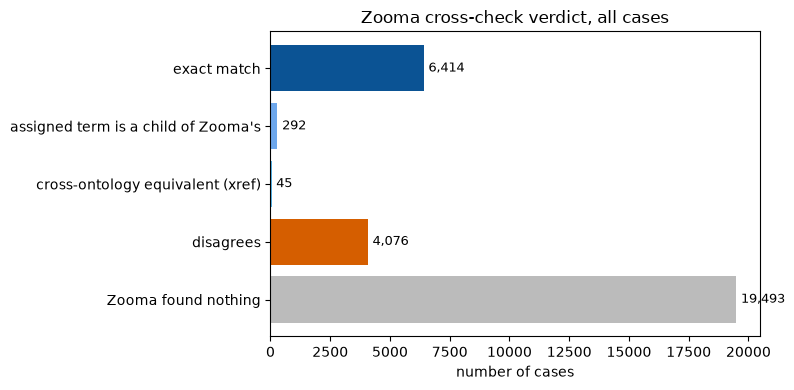

In [6]:
# OVERALL VERDICT BREAKDOWN
def plot_verdict_breakdown(
    counts: pd.Series, figsize: tuple[float, float] = (8, 4)
) -> None:
    _fig, ax = plt.subplots(figsize=figsize)
    labels = [VERDICT_LABELS[v] for v in counts.index]
    bars = ax.barh(
        labels, counts.values, color=[VERDICT_COLORS[v] for v in counts.index]
    )
    for bar, value in zip(bars, counts.values):
        ax.text(
            bar.get_width() + counts.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}",
            va="center",
            fontsize=9,
        )
    ax.set_xlabel("number of cases")
    ax.set_title("Zooma cross-check verdict, all cases")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


plot_verdict_breakdown(verdict_counts)

## Agreement rate by target field

Restricted to cases Zooma returned a confident candidate for -- `no_zooma_result` cases are a coverage gap, not a disagreement, and are shown separately above.

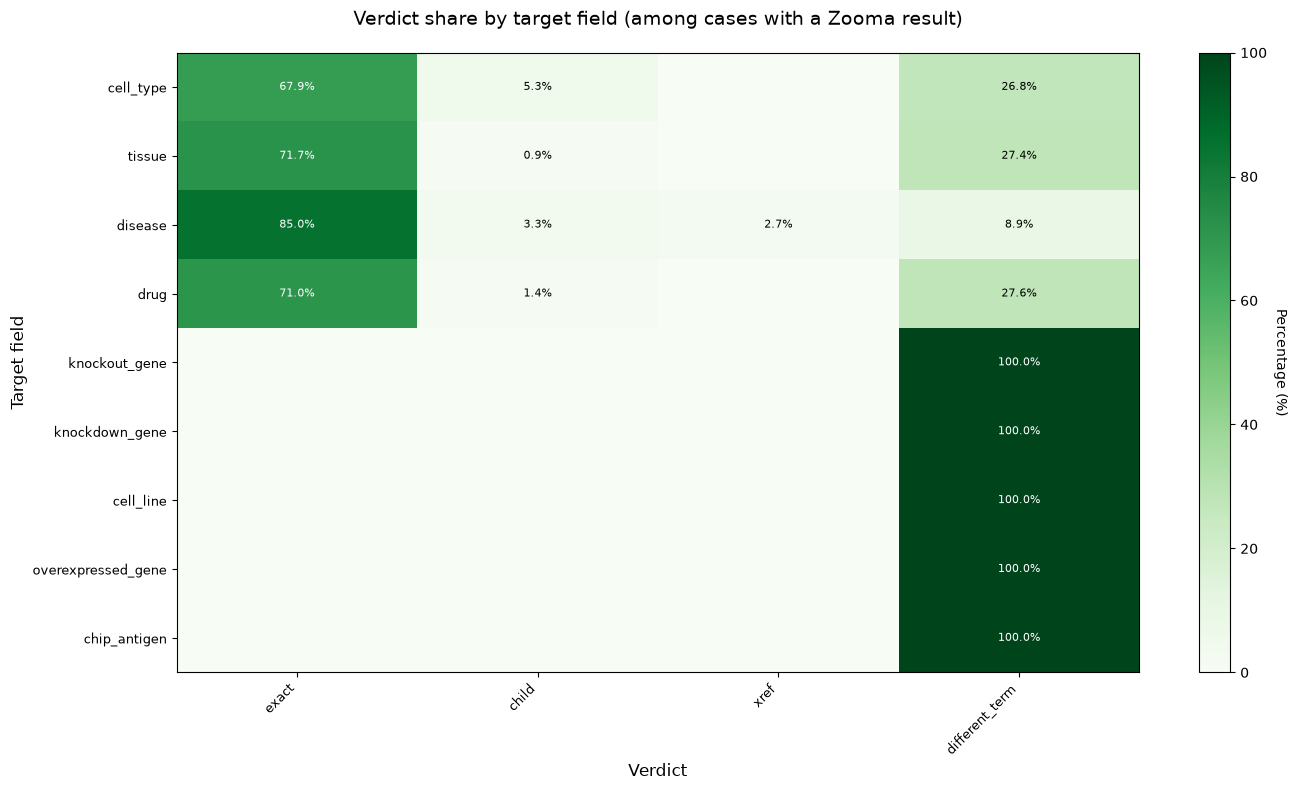

In [7]:
# AGREEMENT RATE BY TARGET FIELD, AS A HEATMAP (VERDICT SHARE AMONG CASES WITH A ZOOMA RESULT)
def verdict_share_table(
    df: pd.DataFrame, group_col: str, verdict_subset: list[str]
) -> pd.DataFrame:
    with_result = df[df["verdict"] != "no_zooma_result"]
    counts = with_result.groupby([group_col, "verdict"]).size().unstack(fill_value=0)
    counts = counts.reindex(columns=verdict_subset, fill_value=0)
    order = with_result[group_col].value_counts().index
    return (100 * counts.div(counts.sum(axis=1), axis=0)).reindex(order)


by_field = verdict_share_table(
    scored, "target_field", ["exact", "child", "xref", "different_term"]
)
plot_heatmap_table(
    by_field,
    title="Verdict share by target field (among cases with a Zooma result)",
    xlabel="Verdict",
    ylabel="Target field",
)

## Agreement rate by originating (non-exact) matching strategy

This is the comparison the notebook opened with: do the cascade's different non-exact strategies for finding evidence text carry different risk of landing on the wrong ontology term?

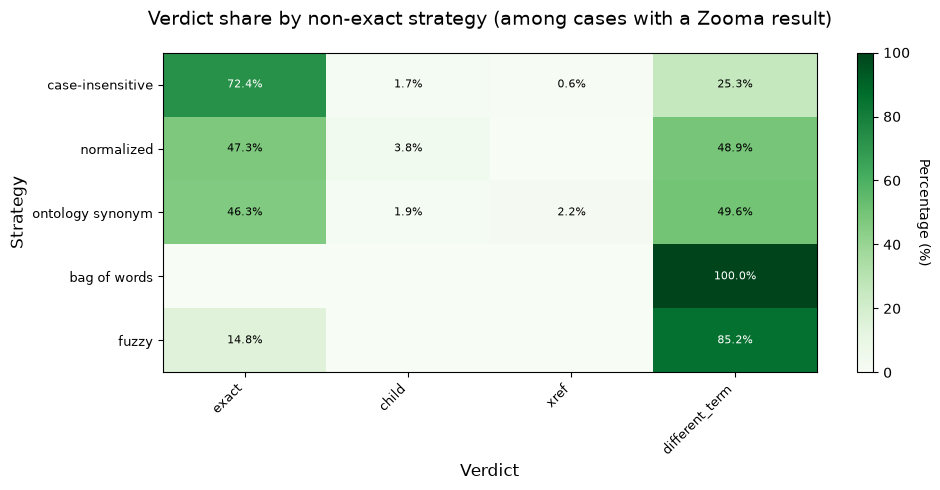

In [8]:
# AGREEMENT RATE BY STRATEGY
by_strategy = verdict_share_table(
    scored, "strategy", ["exact", "child", "xref", "different_term"]
).reindex(NON_EXACT_STRATEGIES)
plot_heatmap_table(
    by_strategy,
    title="Verdict share by non-exact strategy (among cases with a Zooma result)",
    xlabel="Verdict",
    ylabel="Strategy",
    figsize=(10, 5),
)

## When they disagree, which ontology does Zooma reach for instead?

The `different_term` bucket is where a wrong *ontology*, not just a wrong term, would show up: Zooma's top candidate coming from a different ontology than the one the pipeline assumed for that target field.

In [9]:
# FOR "different_term" CASES: WHICH ONTOLOGY DOES ZOOMA'S TOP CANDIDATE COME FROM
def top_candidate_ontology(term_id: str | None) -> str | None:
    if not term_id:
        return None
    token = term_id.replace(":", "_", 1) if ":" in term_id else term_id
    return token.split("_", 1)[0].upper() if "_" in token else None


disagreements = scored[scored["verdict"] == "different_term"].copy()
disagreements["assigned_ontology"] = disagreements["assigned_term_id"].map(
    top_candidate_ontology
)
disagreements["candidate_ontology"] = disagreements["top_candidate_term_id"].map(
    top_candidate_ontology
)

ontology_mismatch = (
    disagreements.groupby(["target_field", "assigned_ontology", "candidate_ontology"])
    .size()
    .rename("n_cases")
    .reset_index()
    .sort_values("n_cases", ascending=False)
)
ontology_mismatch.head(20).style.format({"n_cases": "{:,}"})

,target_field,assigned_ontology,candidate_ontology,n_cases
102,knockout_gene,NCBIGENE,OMIT,717
93,knockdown_gene,NCBIGENE,OMIT,706
7,cell_type,CL,BTO,401
133,tissue,UBERON,NCIT,177
8,cell_type,CL,CL,135
3,cell_line,CVCL,EFO,132
100,knockout_gene,NCBIGENE,NCIT,111
114,tissue,UBERON,BTO,111
19,cell_type,CL,NCIT,108
109,overexpressed_gene,NCBIGENE,OMIT,87


In [10]:
# SAME-ONTOLOGY DISAGREEMENT (WRONG TERM WITHIN THE RIGHT ONTOLOGY) VS. A GENUINELY DIFFERENT ONTOLOGY
same_ontology = (
    disagreements["assigned_ontology"] == disagreements["candidate_ontology"]
)
n_same_ontology = same_ontology.sum()
n_different_ontology = (~same_ontology).sum()

md(
    f"Of the **{len(disagreements):,}** `different_term` cases, Zooma's top candidate lands in the **same** ontology "
    f"the pipeline already assumed for **{n_same_ontology:,}** ({100 * n_same_ontology / len(disagreements):.1f}%) -- "
    "a wrong *term*, not a wrong *ontology* -- and in a **different** ontology entirely for "
    f"**{n_different_ontology:,}** ({100 * n_different_ontology / len(disagreements):.1f}%), which is where the "
    "notebook's opening question (is the ontology itself right?) actually bites."
)

Of the **4,076** `different_term` cases, Zooma's top candidate lands in the **same** ontology the pipeline already assumed for **213** (5.2%) -- a wrong *term*, not a wrong *ontology* -- and in a **different** ontology entirely for **3,863** (94.8%), which is where the notebook's opening question (is the ontology itself right?) actually bites.

## Example disagreements

In [11]:
# A RANDOM SAMPLE OF "different_term" CASES FOR MANUAL EYEBALLING
example_columns = [
    "target_field",
    "raw_field",
    "raw_matched_phrase",
    "assigned_term_label",
    "assigned_term_id",
    "top_candidate_label",
    "top_candidate_term_id",
    "strategy",
]
examples = disagreements[example_columns].sample(
    min(25, len(disagreements)), random_state=42
)
display_with_nested_tables(examples)

target_field,raw_field,raw_matched_phrase,assigned_term_label,assigned_term_id,top_candidate_label,top_candidate_term_id,strategy
drug,comment,interleukin-6,doxycycline,CHEBI:50845,Interleukin-6,OMIT_0016485,case-insensitive
disease,cell type,Pancreas cancer,malignant pancreatic neoplasm,MONDO:0009831,Pancreatic Carcinoma,NCIT_C207229,ontology synonym
cell_type,cd8 t cells,CD8 T cell,T cell,CL:0000084,"CD8-positive, alpha-beta T cell",CL_0000625,normalized
chip_antigen,genotype,Smchd1,Smchd1,NCBIGene:74355,SMCHD1,OMIT_0039477,normalized
drug,mood medications,Valproic acid,haloperidol,CHEBI:5613,Valproic Acid,OMIT_0015469,case-insensitive
cell_type,cell type,Leiomyoma cell,myometrial cell,CL:0002366,leiomyoma cell,BTO_0002694,normalized
cell_type,source_name,Papillary thyroid cancer cell,malignant cell,CL:0001064,papillary thyroid cancer cell,BTO_0003152,normalized
cell_type,cell type,lung adenocarcinoma cell,epithelial cell of lung,CL:0000082,lung adenocarcinoma cell,BTO_0002057,normalized
knockdown_gene,Ids.Id,ALKBH5,ALKBH5,NCBIGene:54890,ALKBH5,OMIT_0042559,normalized
chip_antigen,chip-grade antibody,Ruvbl2,RUVBL2,NCBIGene:10856,RUVBL2,OMIT_0038646,case-insensitive


## Limitations

- **Coverage gap.** Zooma returned nothing at all for a majority of evidence phrases (see the coverage table above) -- many are short fragments (single words, abbreviations, gene/construct names) that its text tagger doesn't recognize as an annotatable span. `no_zooma_result` should be read as "not checkable this way", not as a disagreement.
- **NCBIGene and Cellosaurus (CVCL) are not OLS-lookupable ontologies.** Gene-symbol and cell-line fields can only ever land in `exact`/`different_term`/`no_zooma_result` here -- `child`/`xref` structural checks were never possible for them, independent of how well-curated the pipeline's own assignment is.
- **`xref` only counts a declared real-equivalence cross-reference** (e.g. MONDO's `"MONDO:equivalentTo"` tag), not every cross-reference an ontology carries -- MONDO in particular also ships much looser ones (e.g. `"MONDO:otherHierarchy"`, or a curator's bare ORCID as the description) that point at a related-but-not-equivalent term; an earlier version of this check counted those too and produced a real false positive (`"diabetes mellitus"` matched via an `otherHierarchy` xref to a Human Phenotype Ontology term for abnormal glucose homeostasis -- related, not the same thing) before being tightened.
- **`child` is checked in one direction only:** is the pipeline's assigned term a descendant of a Zooma candidate. It does not check the reverse (assigned term more general than what Zooma proposed).
- **Confidence threshold.** Only Zooma candidates at or above `zooma_scoring.CONFIDENCE_THRESHOLD` (stated in the headline-numbers cell above) are considered; a lower/no threshold would raise `no_zooma_result`'s complement at the cost of noisier candidates.
- **Open-ontology search surfaces some clearly-irrelevant ontologies** (e.g. WikiPathways, NCIT pathway diagrams, AMPHX) alongside genuine anatomical/disease/chemical ones -- `different_term` includes real disagreements and cases where Zooma's best guess is simply off-topic for what the field represents.

## Summary

In [12]:
# SUMMARY NUMBERS, COMPUTED LIVE
md(
    f"- **{len(cases):,}** unique non-exact-strategy cases checked; Zooma returned a confident candidate for "
    f"**{len(with_result):,}** ({100 * len(with_result) / len(cases):.1f}%).\n"
    f"- Among those, **{n_agree:,}** ({100 * n_agree / len(with_result):.1f}%) agree with the pipeline's assigned term "
    "(exact, a more specific child term, or a real cross-ontology equivalent).\n"
    f"- **{verdict_counts['different_term']:,}** cases ({100 * verdict_counts['different_term'] / len(with_result):.1f}% of those with a result) "
    "point to a Zooma candidate structurally unrelated to the assigned term -- see the ontology-mismatch table and example disagreements above for where to look first.\n"
    "- Gene-symbol and cell-line fields (NCBIGene, Cellosaurus) are not checkable via this method at all -- Zooma/OLS don't index them as ontology classes."
)

- **30,320** unique non-exact-strategy cases checked; Zooma returned a confident candidate for **10,827** (35.7%).
- Among those, **6,751** (62.4%) agree with the pipeline's assigned term (exact, a more specific child term, or a real cross-ontology equivalent).
- **4,076** cases (37.6% of those with a result) point to a Zooma candidate structurally unrelated to the assigned term -- see the ontology-mismatch table and example disagreements above for where to look first.
- Gene-symbol and cell-line fields (NCBIGene, Cellosaurus) are not checkable via this method at all -- Zooma/OLS don't index them as ontology classes.